# Entrega 1 — EDA y Baseline
## Sistema de Recomendación de Películas: MovieLens 100K

**Curso:** Aprendizaje de Máquina Aplicado — EAFIT  
**Profesor:** Marco Teran  
**Dataset:** MovieLens 100K — GroupLens Research  
**Fecha límite:** 23/04/2026  

---

### Pregunta central
> ¿Es posible predecir el rating (1–5) que un usuario le daría a una película que no ha visto?

In [1]:
import warnings

# Data manipulatio
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuration
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


In [3]:
# Path to raw data
DATA_PATH = '../data/raw/ml-100k/'

# Ratings
ratings = pd.read_csv(
    DATA_PATH + 'u.data',
    sep='\t',
    names=['user_id', 'item_id', 'rating', 'timestamp']
)

# Users
users = pd.read_csv(
    DATA_PATH + 'u.user',
    sep='|',
    names=['user_id', 'age', 'gender', 'occupation', 'zip_code']
)

# Movies
movie_cols = [
    'item_id', 'title', 'release_date', 'video_release_date', 'imdb_url',
    'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

movies = pd.read_csv(
    DATA_PATH + 'u.item',
    sep='|',
    encoding='latin-1',
    names=movie_cols
)

print(f"Ratings:  {ratings.shape[0]:,} rows × {ratings.shape[1]} columns")
print(f"Users:    {users.shape[0]:,} rows × {users.shape[1]} columns")
print(f"Movies:   {movies.shape[0]:,} rows × {movies.shape[1]} columns")

Ratings:  100,000 rows × 4 columns
Users:    943 rows × 5 columns
Movies:   1,682 rows × 24 columns


In [5]:
ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [6]:
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [7]:
movies.head()

,item_id,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [8]:
# --- Ratings ---
print("=" * 45)
print("RATINGS")
print("=" * 45)
print(ratings.isnull().sum())
print(f"\nDuplicates: {ratings.duplicated().sum()}")
print(f"Rating range: {ratings['rating'].min()} – {ratings['rating'].max()}")

# --- Users ---
print("\n" + "=" * 45)
print("USERS")
print("=" * 45)
print(users.isnull().sum())

# --- Movies ---
print("\n" + "=" * 45)
print("MOVIES")
print("=" * 45)
print(movies.isnull().sum())

RATINGS
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

Duplicates: 0
Rating range: 1 – 5

USERS
user_id       0
age           0
gender        0
occupation    0
zip_code      0
dtype: int64

MOVIES
item_id                  0
title                    0
release_date             1
video_release_date    1682
imdb_url                 3
unknown                  0
Action                   0
Adventure                0
Animation                0
Children                 0
Comedy                   0
Crime                    0
Documentary              0
Drama                    0
Fantasy                  0
Film-Noir                0
Horror                   0
Musical                  0
Mystery                  0
Romance                  0
Sci-Fi                   0
Thriller                 0
War                      0
Western                  0
dtype: int64


## Hallazgos de calidad de datos

- **Ratings**: sin nulos, sin duplicados, rango válido (1–5). ✓
- **Users**: sin nulos en ninguna columna. ✓
- **Movies**:
  - `video_release_date`: 1,682/1,682 nulos → se descarta completamente.
  - `imdb_url`: sin valor predictivo → se descarta.
  - `release_date`: 1 nulo → se conserva, se tratará al extraer el año.
  - Columnas de géneros: sin nulos, codificación binaria correcta. ✓

In [ ]:
# Drop columns with no predictive value
movies.drop(columns=['video_release_date', 'imdb_url'], inplace=True)

In [15]:
print(f"Movies columns after cleaning: {movies.shape[1]}")
print(movies.columns.tolist())

Movies columns after cleaning: 22
['item_id', 'title', 'release_date', 'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [16]:
# Extract release year from release_date
movies['release_year'] = pd.to_datetime(
    movies['release_date'], errors='coerce'
).dt.year

# Check the result
print(movies[['title', 'release_date', 'release_year']].head(10))
print(f"\nNulls in release_year: {movies['release_year'].isnull().sum()}")
print(f"Year range: {movies['release_year'].min():.0f} – {movies['release_year'].max():.0f}")

                                               title release_date  \
0                                   Toy Story (1995)  01-Jan-1995   
1                                   GoldenEye (1995)  01-Jan-1995   
2                                  Four Rooms (1995)  01-Jan-1995   
3                                  Get Shorty (1995)  01-Jan-1995   
4                                     Copycat (1995)  01-Jan-1995   
5  Shanghai Triad (Yao a yao yao dao waipo qiao) ...  01-Jan-1995   
6                              Twelve Monkeys (1995)  01-Jan-1995   
7                                        Babe (1995)  01-Jan-1995   
8                            Dead Man Walking (1995)  01-Jan-1995   
9                                 Richard III (1995)  22-Jan-1996   

   release_year  
0        1995.0  
1        1995.0  
2        1995.0  
3        1995.0  
4        1995.0  
5        1995.0  
6        1995.0  
7        1995.0  
8        1995.0  
9        1996.0  

Nulls in release_year: 1
Year range: 1922

In [17]:
# Fill the single null with the median year
median_year = movies['release_year'].median()
movies['release_year'] = movies['release_year'].fillna(median_year)

print(f"Null filled with median year: {median_year:.0f}")
print(f"Nulls remaining: {movies['release_year'].isnull().sum()}")

Null filled with median year: 1995
Nulls remaining: 0


## Análisis Exploratorio de Datos (EDA)

### 1. Distribución de ratings

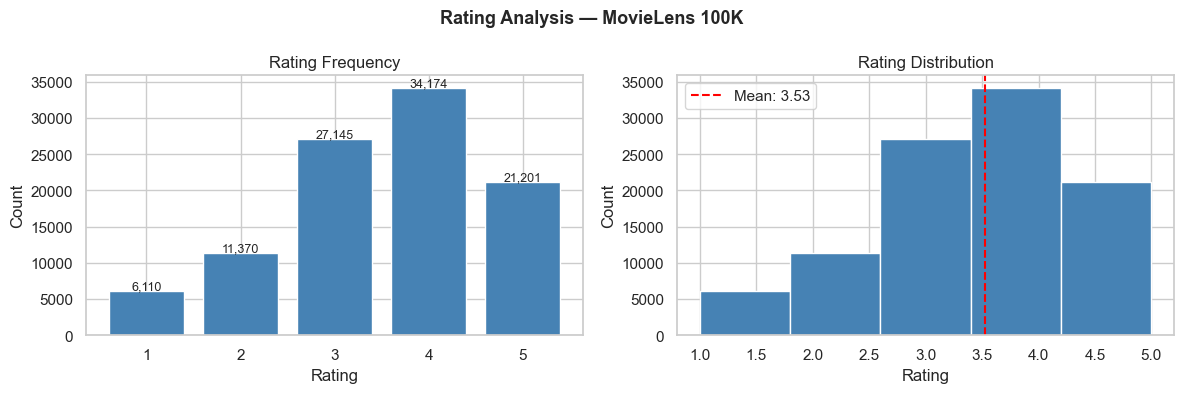

Global mean rating : 3.5299
Standard deviation : 1.1257
Median             : 4.0


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating counts
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Frequency')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for i, v in zip(rating_counts.index, rating_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Cumulative distribution
mean_rating = ratings['rating'].mean()
axes[1].hist(ratings['rating'], bins=5, color='steelblue', edgecolor='white')
axes[1].axvline(mean_rating, color='red', linestyle='--', label=f'Mean: {mean_rating:.2f}')
axes[1].set_title('Rating Distribution')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Rating Analysis — MovieLens 100K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/01_rating_distribution.png', bbox_inches='tight')
plt.show()

print(f"Global mean rating : {mean_rating:.4f}")
print(f"Standard deviation : {ratings['rating'].std():.4f}")
print(f"Median             : {ratings['rating'].median():.1f}")

**Hallazgo:** Los ratings muestran sesgo de positividad — la media (~3.5) está por encima 
del punto medio de la escala (3.0). Ratings 3 y 4 concentran la mayoría de las interacciones. 
Esto implica que un baseline de media global ya captura parte del patrón.

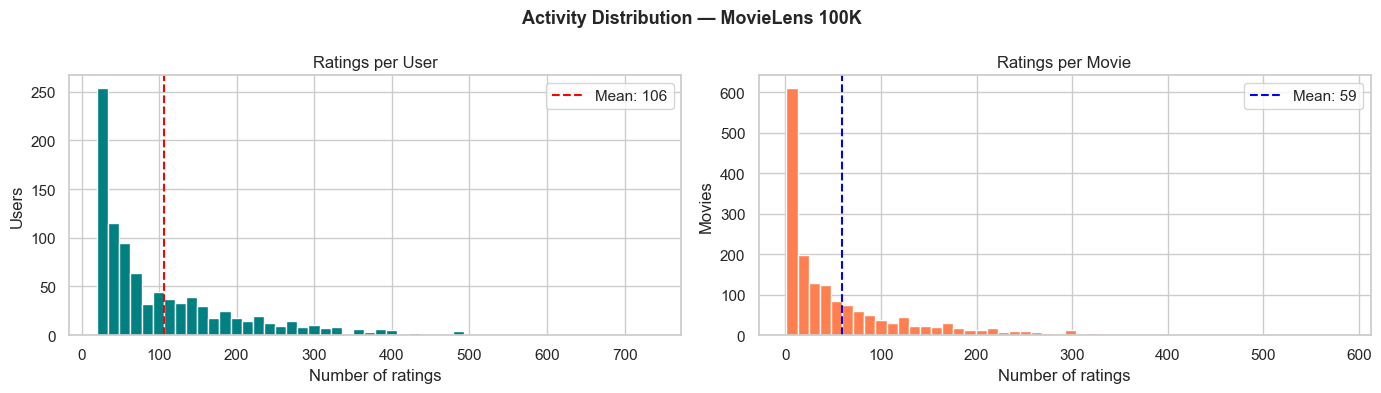

Unique users  : 943
Unique movies : 1,682
Total ratings : 100,000
Matrix size   : 943 × 1682 = 1,586,126 possible ratings
Sparsity      : 93.70%


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ratings_per_user  = ratings.groupby('user_id')['rating'].count()
ratings_per_movie = ratings.groupby('item_id')['rating'].count()

# Ratings per user
axes[0].hist(ratings_per_user, bins=50, color='teal', edgecolor='white')
axes[0].set_title('Ratings per User')
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Users')
axes[0].axvline(ratings_per_user.mean(), color='red', linestyle='--',
                label=f'Mean: {ratings_per_user.mean():.0f}')
axes[0].legend()

# Ratings per movie
axes[1].hist(ratings_per_movie, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Ratings per Movie')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Movies')
axes[1].axvline(ratings_per_movie.mean(), color='blue', linestyle='--',
                label=f'Mean: {ratings_per_movie.mean():.0f}')
axes[1].legend()

plt.suptitle('Activity Distribution — MovieLens 100K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/02_activity_distribution.png', bbox_inches='tight')
plt.show()

# Sparsity
n_users   = ratings['user_id'].nunique()
n_movies  = ratings['item_id'].nunique()
n_ratings = len(ratings)
sparsity  = 1 - (n_ratings / (n_users * n_movies))

print(f"Unique users  : {n_users:,}")
print(f"Unique movies : {n_movies:,}")
print(f"Total ratings : {n_ratings:,}")
print(f"Matrix size   : {n_users} × {n_movies} = {n_users * n_movies:,} possible ratings")
print(f"Sparsity      : {sparsity:.2%}")

**Hallazgo:** La matriz usuario–película tiene una sparsity del 93.70% — solo 100,000 de 
1,586,126 combinaciones posibles tienen rating. Ambas distribuciones muestran cola larga: 
pocos usuarios y pocas películas concentran la mayoría de interacciones. Esto introduce 
el problema de **cold start**: el modelo tendrá menor precisión para usuarios con pocas 
calificaciones y películas poco vistas.

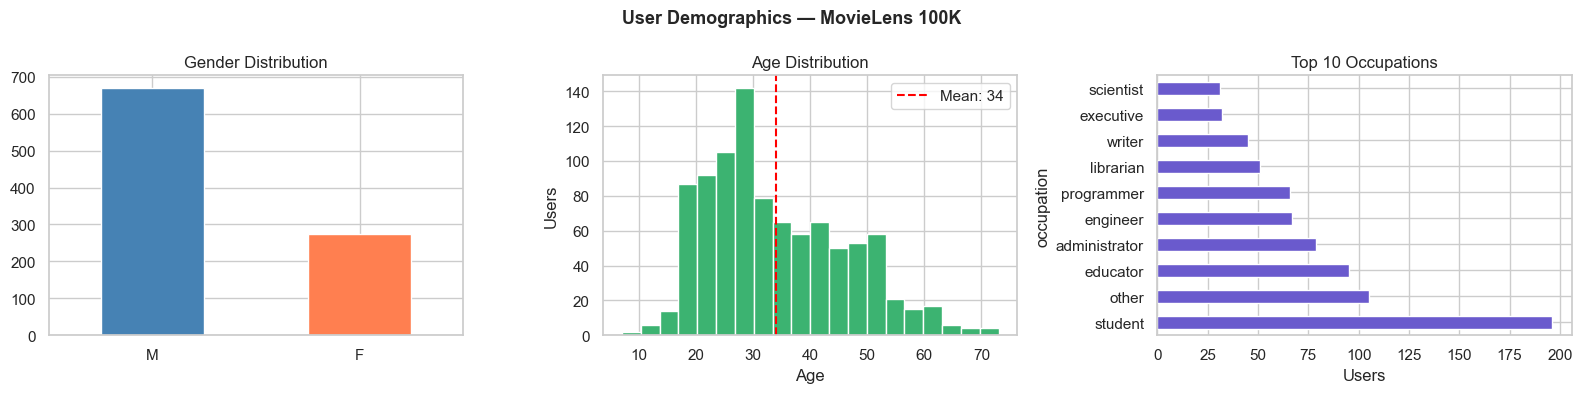

Gender breakdown:
gender
M    670
F    273
Name: count, dtype: int64

Age — mean: 34.1, median: 31


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Gender
users['gender'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)

# Age
axes[1].hist(users['age'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Users')
axes[1].axvline(users['age'].mean(), color='red', linestyle='--',
                label=f'Mean: {users["age"].mean():.0f}')
axes[1].legend()

# Top 10 occupations
users['occupation'].value_counts().head(10).plot(
    kind='barh', ax=axes[2], color='slateblue', edgecolor='white')
axes[2].set_title('Top 10 Occupations')
axes[2].set_xlabel('Users')

plt.suptitle('User Demographics — MovieLens 100K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/03_user_demographics.png', bbox_inches='tight')
plt.show()

print(f"Gender breakdown:\n{users['gender'].value_counts()}")
print(f"\nAge — mean: {users['age'].mean():.1f}, median: {users['age'].median():.0f}")

In [21]:
print(f"Age stats:")
print(f"  Min    : {users['age'].min()}")
print(f"  Max    : {users['age'].max()}")
print(f"  Mean   : {users['age'].mean():.1f}")
print(f"  Median : {users['age'].median():.0f}")
print(f"\nUsers older than 60: {(users['age'] > 60).sum()}")
print(f"Users younger than 18: {(users['age'] < 18).sum()}")

Age stats:
  Min    : 7
  Max    : 73
  Mean   : 34.1
  Median : 31

Users older than 60: 22
Users younger than 18: 36


**Hallazgo:** El perfil demográfico muestra sesgo significativo — aproximadamente 3 de cada 4 
usuarios son hombres, la ocupación más frecuente es estudiante, y aunque el rango de edad 
es amplio (7–73 años), la mediana es 31. La media (34.1) está jalada por usuarios mayores. 
El modelo aprenderá principalmente de las preferencias de hombres jóvenes, lo que limita 
su generalización a otros perfiles demográficos.

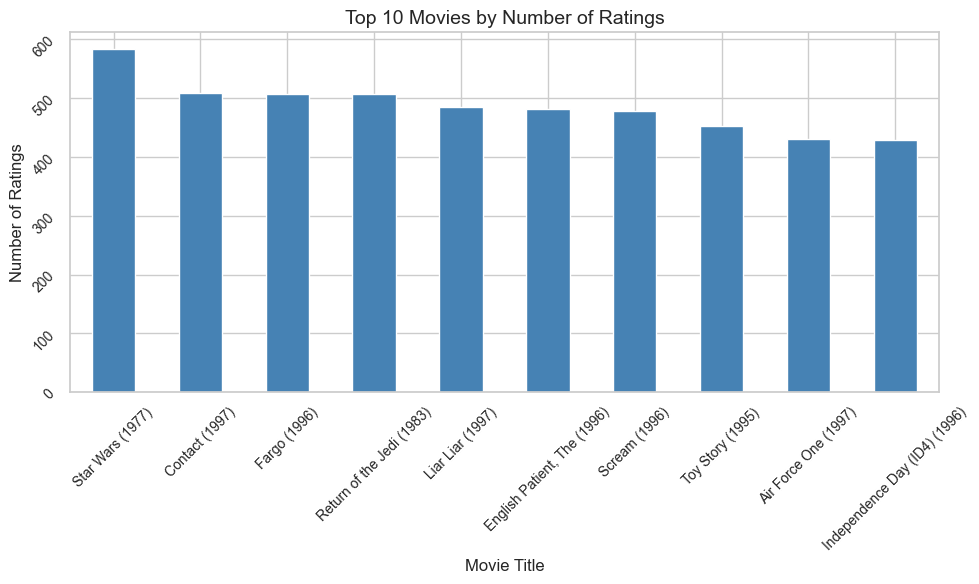

In [ ]:
top_10_movies = (
    movies.merge(ratings, on='item_id')
    .groupby('title')
    .size()
    .reset_index(name='ratings_count')
    .sort_values(by='ratings_count', ascending=False)
    .head(10)
)
fig, ax = plt.subplots(figsize=(10, 6))

top_10_movies.plot(
    kind='bar', 
    x='title', 
    y='ratings_count', 
    ax=ax,
    color='steelblue', 
    edgecolor='white',
    legend=False
)


ax.set_title('Top 10 Movies by Number of Ratings', fontsize=14)
ax.set_xlabel('Movie Title', fontsize=12)
ax.set_ylabel('Number of Ratings', fontsize=12)
ax.tick_params(rotation=45, labelsize=10)
plt.tight_layout()
plt.show()

**Hallazgo:** el dataset refleja una preferencia generacional: la mayoría de los ratings se concentran en estrenos de los años 90. Dado que el perfil predominante es el de estudiantes jóvenes, existe una correlación clara entre la juventud del público y el consumo de cine reciente. Esto demuestra que, para este grupo, la relevancia de una película está fuertemente ligada a su fecha de lanzamiento.

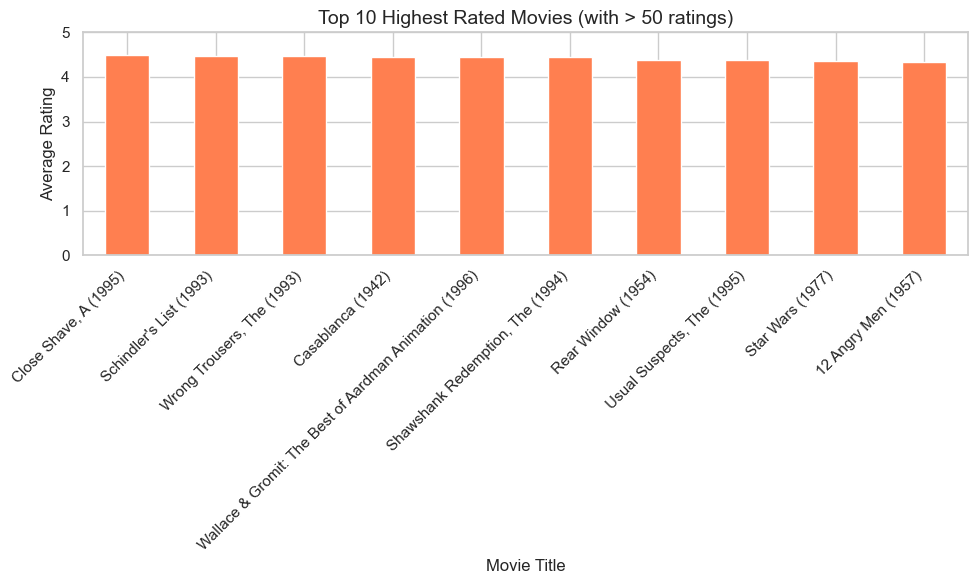

In [91]:
top_rated_movies = (
    movies.merge(ratings, on='item_id')
    .groupby('title', as_index=False)['rating']
    .agg(count_r='count', avg_rating='mean')
    .query('count_r > 50')
    .sort_values(by='avg_rating', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))

top_rated_movies.plot(
    kind='bar', 
    x='title', 
    y='avg_rating', 
    ax=ax, 
    color='coral', 
    edgecolor='white',
    legend=False
)


ax.set_title('Top 10 Highest Rated Movies (with > 50 ratings)', fontsize=14)
ax.set_xlabel('Movie Title', fontsize=12)
ax.set_ylabel('Average Rating', fontsize=12)

ax.set_ylim(0, 5.0) 


plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Hallazgo:** existe una distinción clara entre lo que es tendencia y lo que es aclamado. Aunque los usuarios muestran una inclinación natural hacia el cine reciente, los datos confirman que la calidad no tiene fecha de caducidad. Películas con menor frecuencia de voto, pero mayor antigüedad, mantienen promedios superiores, lo que sugiere que el público sigue otorgando un valor especial a los clásicos que han logrado trascender su época.

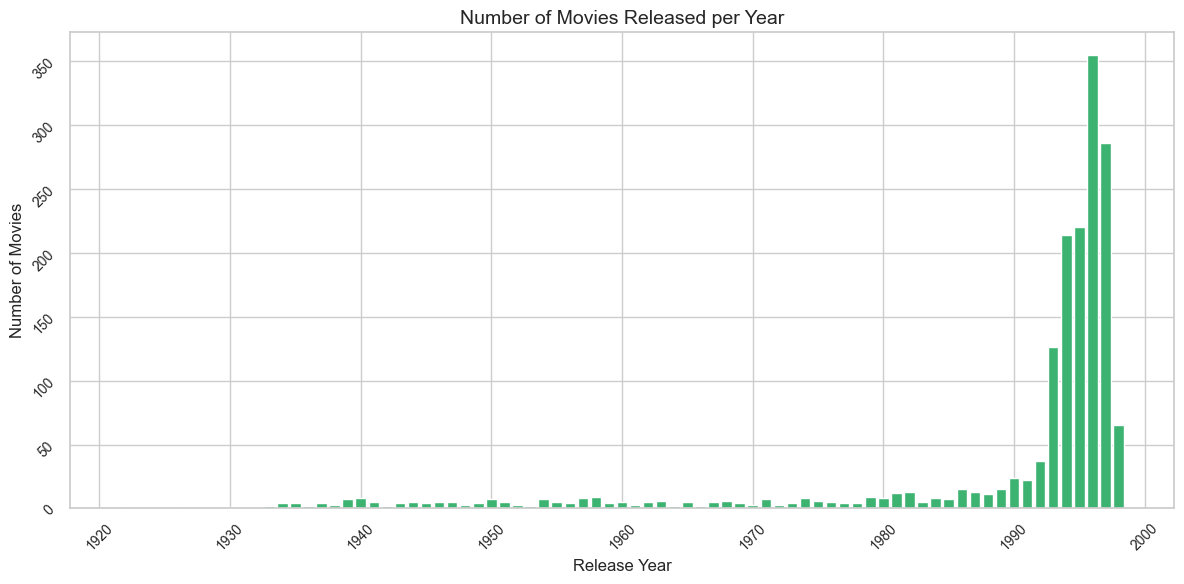

In [72]:
year_counts = (
    movies.groupby('release_year')
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(year_counts['release_year'], year_counts['count'], color='mediumseagreen', edgecolor='white')
ax.set_title('Number of Movies Released per Year', fontsize=14)
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.tick_params(rotation=45, labelsize=10)
plt.tight_layout()
plt.show()

**Hallazgo:** el gráfico muestra que la base de datos refleja un boom del cine en los años 90's, ya que allí se concentra la mayor parte de la información sobre películas.

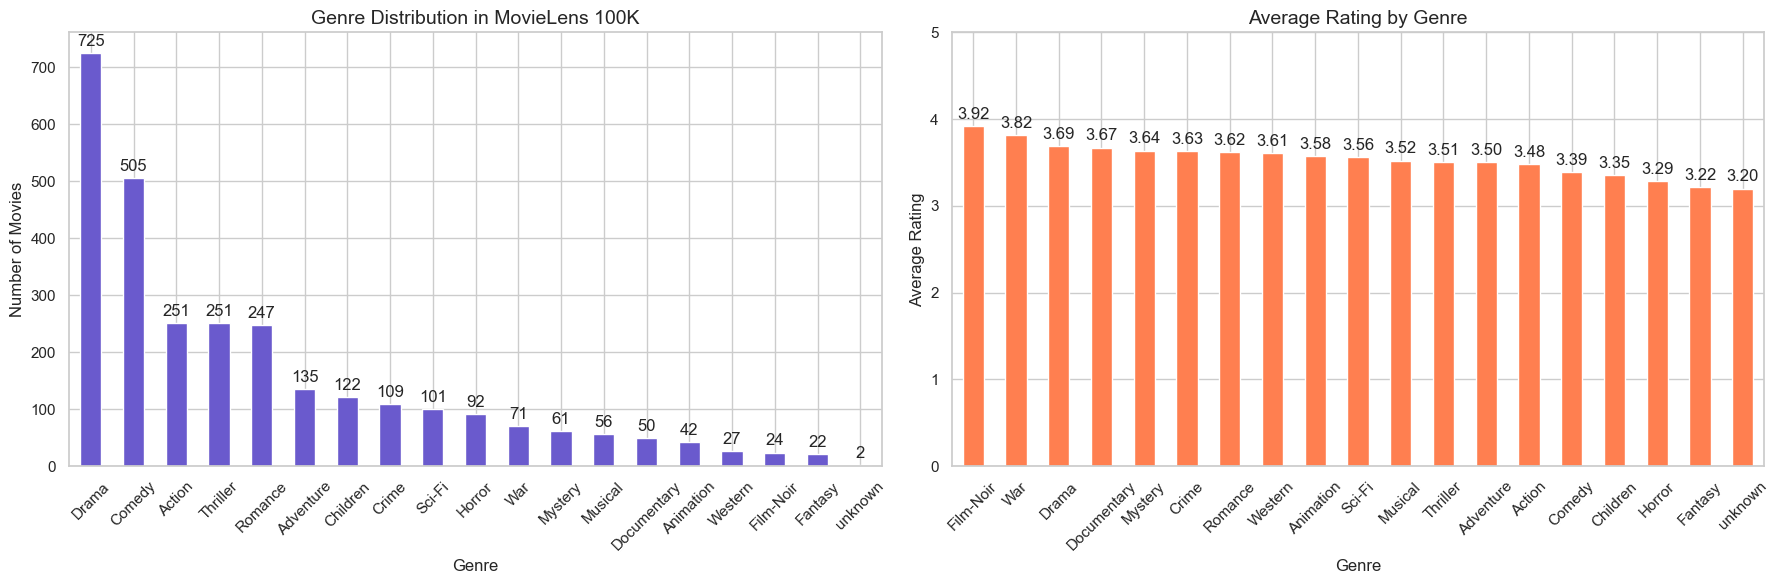

In [97]:
# Obtenemos la lista de géneros (todas las columnas excepto las de metadata)
genres= movies.columns.difference(['item_id', 'title', 'release_date', 'release_year'])
# Contamos cuántas películas hay de cada género sumando las columnas binarias
genre_counts = movies[genres].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

genre_counts.plot(kind='bar', color='slateblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Genre Distribution in MovieLens 100K', fontsize=14)
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Number of Movies')
axes[0].tick_params(axis='x', rotation=45)
axes[0].bar_label(axes[0].containers[0], fmt='%d', padding=3)

# Para calcular el promedio de rating por género, necesitamos hacer un merge entre movies y ratings
merged_df = movies.merge(ratings, on='item_id')

# Calculamos el promedio de rating para cada género
genre_means = {}
for genre in genres:
    genre_means[genre] = merged_df[merged_df[genre] == 1]['rating'].mean()

# Convertimos el diccionario a una Serie de pandas para facilitar la visualización
genre_mean_series = pd.Series(genre_means).sort_values(ascending=False)

genre_mean_series.plot(kind='bar', color='coral', edgecolor='white', ax=axes[1])
axes[1].set_title('Average Rating by Genre', fontsize=14)
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(0, 5.0) # Escala de 0 a 5
axes[1].tick_params(axis='x', rotation=45)
axes[1].bar_label(axes[1].containers[0], fmt='%.2f', padding=3)


plt.tight_layout()
plt.show()

**Hallazgo:** se observa que la abundancia de lanzamientos no garantiza la mejor recepción. Aunque el cine de la época apostaba masivamente por el drama y la comedia, los usuarios mostraron un mayor aprecio por categorías con menor volumen de producción. Esto sugiere que los géneros minoritarios cuentan con un público más fiel y entusiasta, cuya valoración positiva compensa la falta de cantidad, demostrando que el interés de los usuarios es más profundo en secciones específicas de la industria que en el contenido de consumo masivo.